# Gaussian Process Regression & Classification
# Algorithms 2.1, 3.1, and 3.2 : Rasmussen & Williams
# *Gaussian Processes for Machine Learning*

---

# Anuj Rajan Lalla (B22AI061)
# Abhinav Swami (B22AI003)
# Swaksh Patwari (B22AI065)

---

# Interpretation of all the figures and numbers in the report
---

---
# Imports
---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.linalg import cho_factor, cho_solve, cholesky, solve_triangular
from scipy.special import expit  # sigmoid
from scipy.stats import norm
from sklearn.datasets import make_moons, load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_squared_error, r2_score,
                             accuracy_score, log_loss, confusion_matrix,
                             classification_report)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3
})

np.random.seed(42)
print("All imports successful.")

All imports successful.


---
# Part 1: Kernel (Covariance) Functions
---

A Gaussian Process is fully specified by its mean function $m(\mathbf{x})$ and covariance function $k(\mathbf{x}, \mathbf{x}')$.

We implement several common kernels:

| Kernel | Formula |
|--------|---------|
| **Squared Exponential (RBF)** | $k(\mathbf{x}_p, \mathbf{x}_q) = \sigma_f^2 \exp\!\bigl(-\tfrac{1}{2\ell^2}\|\mathbf{x}_p - \mathbf{x}_q\|^2\bigr)$ |
| **Matern 3/2** | $k(r) = \sigma_f^2\bigl(1 + \tfrac{\sqrt{3}\,r}{\ell}\bigr)\exp\!\bigl(-\tfrac{\sqrt{3}\,r}{\ell}\bigr)$ |

In [2]:
class RBFKernel:
    '''Squared Exponential / RBF kernel.
    k(x_p, x_q) = sigma_f^2 * exp(-0.5 * ||x_p - x_q||^2 / length_scale^2)
    '''
    def __init__(self, length_scale=1.0, sigma_f=1.0):
        self.length_scale = length_scale
        self.sigma_f = sigma_f

    def __call__(self, X1, X2):
        sq_dist = np.sum(X1**2, axis=1, keepdims=True) + \
                  np.sum(X2**2, axis=1, keepdims=True).T - \
                  2 * X1 @ X2.T
        return self.sigma_f**2 * np.exp(-0.5 * sq_dist / self.length_scale**2)

    def diag(self, X):
        return np.full(X.shape[0], self.sigma_f**2)

    def __repr__(self):
        return f"RBF(l={self.length_scale:.3f}, sigma_f={self.sigma_f:.3f})"


class Matern32Kernel:
    '''Matern 3/2 kernel.'''
    def __init__(self, length_scale=1.0, sigma_f=1.0):
        self.length_scale = length_scale
        self.sigma_f = sigma_f

    def __call__(self, X1, X2):
        sq_dist = np.sum(X1**2, axis=1, keepdims=True) + \
                  np.sum(X2**2, axis=1, keepdims=True).T - \
                  2 * X1 @ X2.T
        r = np.sqrt(np.maximum(sq_dist, 1e-12))
        s3 = np.sqrt(3) * r / self.length_scale
        return self.sigma_f**2 * (1 + s3) * np.exp(-s3)

    def diag(self, X):
        return np.full(X.shape[0], self.sigma_f**2)

    def __repr__(self):
        return f"Matern3/2(l={self.length_scale:.3f}, sigma_f={self.sigma_f:.3f})"


print("Kernel classes defined.")

Kernel classes defined.


---
# Part 2: Algorithm 2.1 : Gaussian Process Regression
---

**Algorithm 2.1** (Rasmussen & Williams) computes the predictive distribution for GP regression using the Cholesky decomposition for numerical stability.

**Inputs:** $X$ (training inputs), $\mathbf{y}$ (targets), $k$ (covariance function), $\sigma_n^2$ (noise variance), $\mathbf{x}_*$ (test inputs)

**Steps:**
1. $L := \text{cholesky}(K + \sigma_n^2 I)$
2. $\boldsymbol{\alpha} := L^\top \backslash (L \backslash \mathbf{y})$
3. $\bar{f}_* := \mathbf{k}_*^\top \boldsymbol{\alpha}$  — **predictive mean** (Eq. 2.25)
4. $\mathbf{v} := L \backslash \mathbf{k}_*$
5. $\mathbb{V}[f_*] := k(\mathbf{x}_*, \mathbf{x}_*) - \mathbf{v}^\top \mathbf{v}$  — **predictive variance** (Eq. 2.26)
6. $\log p(\mathbf{y}|X) := -\tfrac{1}{2}\mathbf{y}^\top\boldsymbol{\alpha} - \sum_i \log L_{ii} - \tfrac{n}{2}\log 2\pi$  — **log marginal likelihood** (Eq. 2.30)

## 2.1 Implementation

In [3]:
class GPRegressor:
    '''Gaussian Process Regressor implementing Algorithm 2.1.'''

    def __init__(self, kernel, sigma_n=0.1):
        self.kernel = kernel
        self.sigma_n = sigma_n
        self._is_fitted = False

    def fit(self, X, y):
        '''Compute and cache Cholesky factor and alpha.'''
        self.X_train = np.atleast_2d(X)
        self.y_train = y.ravel()
        n = self.X_train.shape[0]

        # Step 2: L = cholesky(K + sigma_n^2 * I)
        K = self.kernel(self.X_train, self.X_train)
        K += self.sigma_n**2 * np.eye(n)
        self.L = cholesky(K, lower=True)

        # Step 3: alpha = L^T \\ (L \\ y)
        tmp = solve_triangular(self.L, self.y_train, lower=True)
        self.alpha = solve_triangular(self.L.T, tmp, lower=False)

        # Log marginal likelihood (Eq. 2.30)
        self.log_marginal_likelihood_ = (
            -0.5 * self.y_train @ self.alpha
            - np.sum(np.log(np.diag(self.L)))
            - 0.5 * n * np.log(2 * np.pi)
        )
        self._is_fitted = True
        return self

    def predict(self, X_star, return_cov=False):
        '''Compute predictive mean and variance at test points.'''
        assert self._is_fitted, "Call fit() first."
        X_star = np.atleast_2d(X_star)

        k_star = self.kernel(self.X_train, X_star)

        # Step 4: predictive mean
        f_mean = k_star.T @ self.alpha

        # Step 5: v = L \\ k_*
        v = solve_triangular(self.L, k_star, lower=True)

        if return_cov:
            k_ss = self.kernel(X_star, X_star)
            f_cov = k_ss - v.T @ v
            return f_mean, f_cov
        else:
            k_ss_diag = self.kernel.diag(X_star)
            f_var = k_ss_diag - np.sum(v**2, axis=0)
            f_var = np.maximum(f_var, 1e-10)
            return f_mean, f_var

    def log_marginal_likelihood(self):
        return self.log_marginal_likelihood_


print("GPRegressor (Algorithm 2.1) implemented.")

GPRegressor (Algorithm 2.1) implemented.


## 2.2 Experiment on 1-D Toy Data

We generate noisy observations from $f(x) = \sin(x) + 0.5\cos(2x)$ and show the GP posterior.

Log marginal likelihood: -18.3608
Kernel: RBF(l=1.000, sigma_f=1.000)


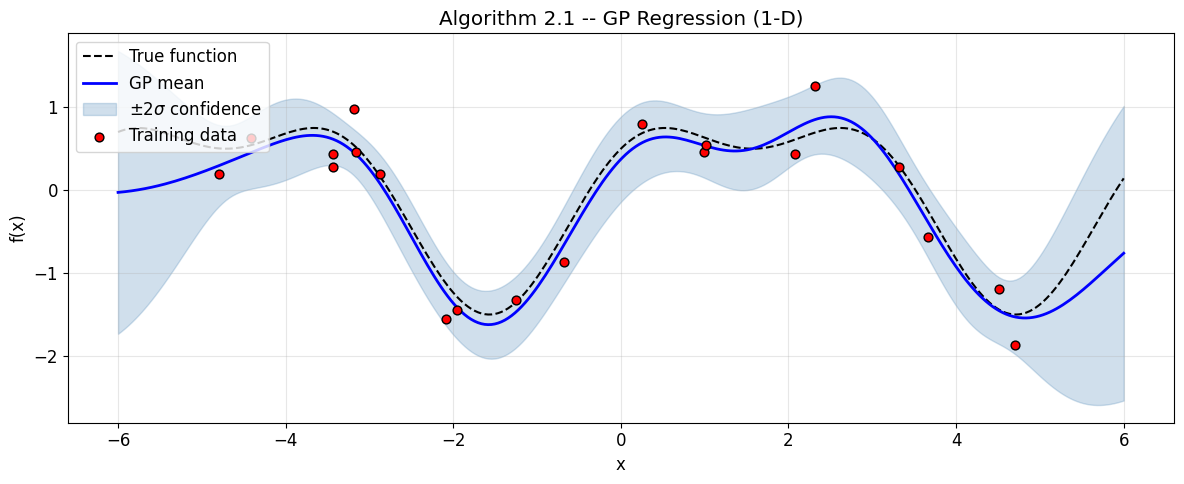

In [4]:
# --- 1-D toy data ---
np.random.seed(42)
n_train = 20
X_train_1d = np.sort(np.random.uniform(-5, 5, n_train)).reshape(-1, 1)
f_true_1d = np.sin(X_train_1d) + 0.5 * np.cos(2 * X_train_1d)
noise_std = 0.3
y_train_1d = (f_true_1d + noise_std * np.random.randn(n_train, 1)).ravel()

X_test_1d = np.linspace(-6, 6, 300).reshape(-1, 1)
f_test_true = (np.sin(X_test_1d) + 0.5 * np.cos(2 * X_test_1d)).ravel()

kernel_rbf = RBFKernel(length_scale=1.0, sigma_f=1.0)
gpr = GPRegressor(kernel=kernel_rbf, sigma_n=noise_std)
gpr.fit(X_train_1d, y_train_1d)
f_mean, f_var = gpr.predict(X_test_1d)
f_std = np.sqrt(f_var)

print(f"Log marginal likelihood: {gpr.log_marginal_likelihood():.4f}")
print(f"Kernel: {kernel_rbf}")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(X_test_1d, f_test_true, 'k--', lw=1.5, label='True function')
ax.plot(X_test_1d, f_mean, 'b-', lw=2, label='GP mean')
ax.fill_between(X_test_1d.ravel(),
                f_mean - 2*f_std, f_mean + 2*f_std,
                alpha=0.25, color='steelblue', label='$\pm 2\sigma$ confidence')
ax.scatter(X_train_1d, y_train_1d, c='red', s=40, zorder=5,
           edgecolors='k', label='Training data')
ax.set_xlabel('x'); ax.set_ylabel('f(x)')
ax.set_title('Algorithm 2.1 -- GP Regression (1-D)')
ax.legend(loc='upper left')
plt.tight_layout(); plt.show()

## 2.3 Sampling from the Prior and Posterior

We draw random function samples from the GP prior and posterior.

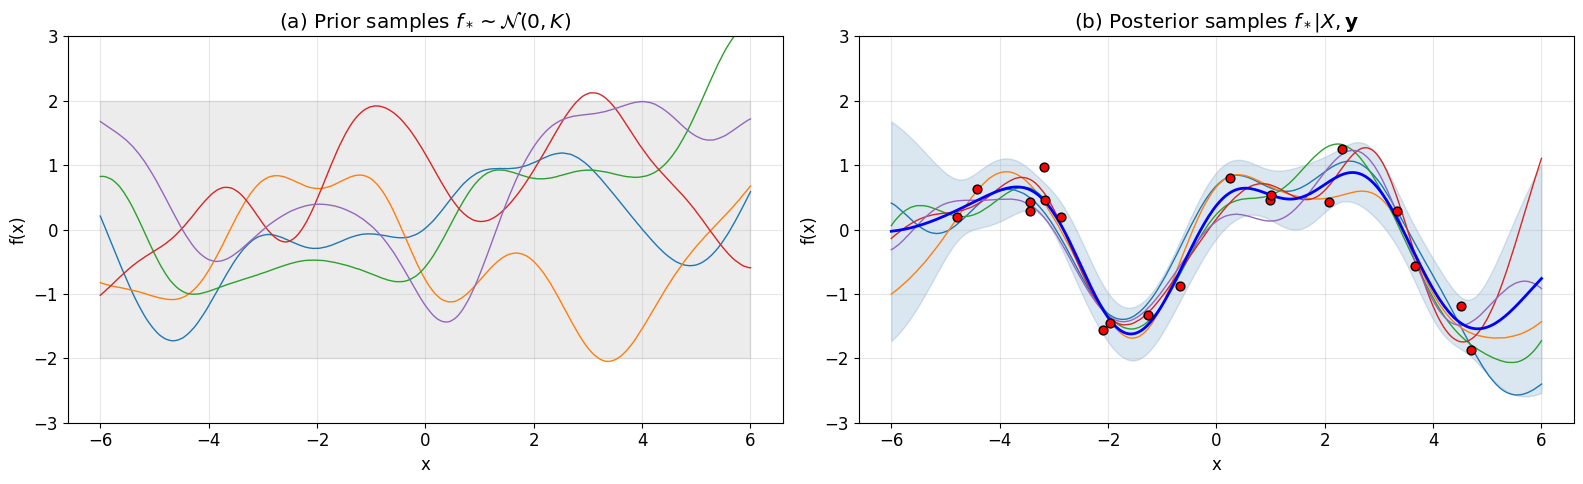

In [5]:
n_samples = 5

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Prior samples
K_prior = kernel_rbf(X_test_1d, X_test_1d) + 1e-6 * np.eye(len(X_test_1d))
L_prior = cholesky(K_prior, lower=True)
for i in range(n_samples):
    z = np.random.randn(len(X_test_1d))
    sample = L_prior @ z
    axes[0].plot(X_test_1d, sample, lw=1)
axes[0].fill_between(X_test_1d.ravel(), -2, 2, alpha=0.15, color='gray')
axes[0].set_title('(a) Prior samples $f_* \sim \mathcal{N}(0, K)$')
axes[0].set_xlabel('x'); axes[0].set_ylabel('f(x)')
axes[0].set_ylim(-3, 3)

# Posterior samples
f_mean_full, f_cov = gpr.predict(X_test_1d, return_cov=True)
f_cov += 1e-6 * np.eye(len(X_test_1d))
L_post = cholesky(f_cov, lower=True)
for i in range(n_samples):
    z = np.random.randn(len(X_test_1d))
    sample = f_mean_full + L_post @ z
    axes[1].plot(X_test_1d, sample, lw=1)
axes[1].scatter(X_train_1d, y_train_1d, c='red', s=40, zorder=5, edgecolors='k')
axes[1].fill_between(X_test_1d.ravel(),
                     f_mean_full - 2*np.sqrt(np.diag(f_cov)),
                     f_mean_full + 2*np.sqrt(np.diag(f_cov)),
                     alpha=0.2, color='steelblue')
axes[1].plot(X_test_1d, f_mean_full, 'b-', lw=2)
axes[1].set_title('(b) Posterior samples $f_* | X, \mathbf{y}$')
axes[1].set_xlabel('x'); axes[1].set_ylabel('f(x)')
axes[1].set_ylim(-3, 3)

plt.tight_layout(); plt.show()

## 2.4 Experiment on a Higher-Dimensional Synthetic Dataset

We apply the GP regressor to a multi-dimensional regression problem to verify the algorithm works beyond 1-D.

Friedman #1 (5-D) -- MSE: 1.9099, R2: 0.9206
Log marginal likelihood: -577.79


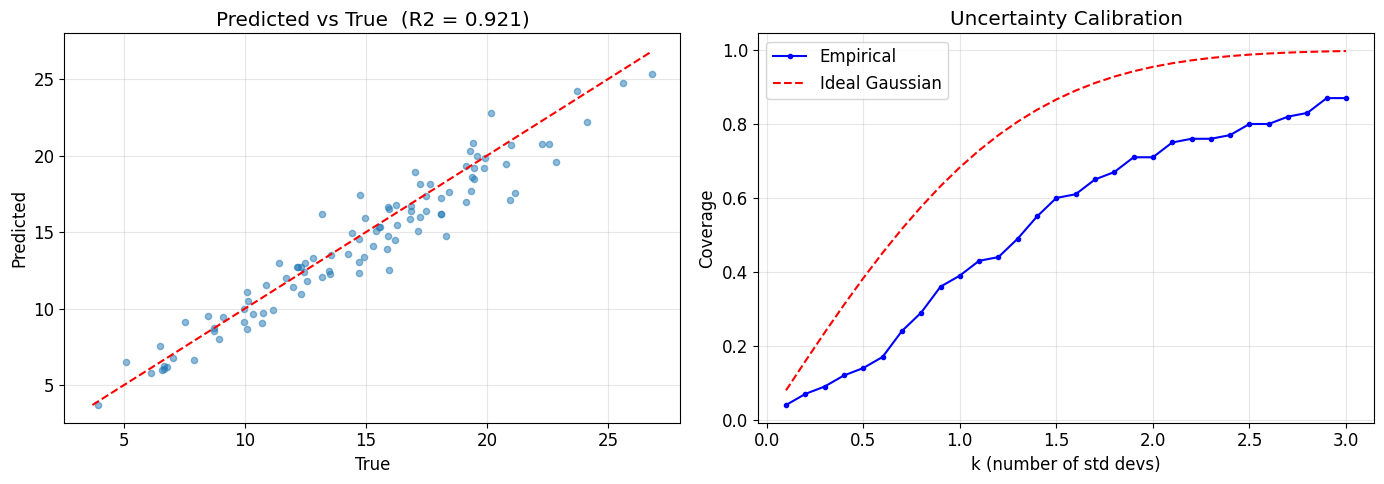

In [6]:
from sklearn.datasets import make_friedman1

# Friedman #1: y = 10*sin(pi*x1*x2) + 20*(x3-0.5)^2 + 10*x4 + 5*x5 + noise
X_fr, y_fr = make_friedman1(n_samples=400, n_features=5, noise=1.0, random_state=42)

scaler_X = StandardScaler()
X_fr = scaler_X.fit_transform(X_fr)

X_h_train, X_h_test, y_h_train, y_h_test = train_test_split(
    X_fr, y_fr, test_size=0.25, random_state=42
)

kernel_fr = RBFKernel(length_scale=2.0, sigma_f=5.0)
gpr_fr = GPRegressor(kernel=kernel_fr, sigma_n=1.0)
gpr_fr.fit(X_h_train, y_h_train)
pred_mean, pred_var = gpr_fr.predict(X_h_test)

mse = mean_squared_error(y_h_test, pred_mean)
r2 = r2_score(y_h_test, pred_mean)
print(f"Friedman #1 (5-D) -- MSE: {mse:.4f}, R2: {r2:.4f}")
print(f"Log marginal likelihood: {gpr_fr.log_marginal_likelihood():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs True
axes[0].scatter(y_h_test, pred_mean, alpha=0.5, s=20)
mn, mx = min(y_h_test.min(), pred_mean.min()), max(y_h_test.max(), pred_mean.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=1.5)
axes[0].set_xlabel('True'); axes[0].set_ylabel('Predicted')
axes[0].set_title(f'Predicted vs True  (R2 = {r2:.3f})')

# Uncertainty calibration
from scipy.stats import norm as norm_dist
k_vals = np.linspace(0.1, 3.0, 30)
fracs = []
for k in k_vals:
    inside = np.abs(y_h_test - pred_mean) < k * np.sqrt(pred_var)
    fracs.append(inside.mean())
expected = 2 * norm_dist.cdf(k_vals) - 1

axes[1].plot(k_vals, fracs, 'b-o', ms=3, label='Empirical')
axes[1].plot(k_vals, expected, 'r--', lw=1.5, label='Ideal Gaussian')
axes[1].set_xlabel('k (number of std devs)'); axes[1].set_ylabel('Coverage')
axes[1].set_title('Uncertainty Calibration')
axes[1].legend()
plt.tight_layout(); plt.show()

## 2.5 Toy 2-D Dataset : Predictive Covariance Visualization

We create training data in $\mathbb{R}^2$ and display the covariance of the GP prediction at a test point $\mathbf{x}_*$ against all other test locations.

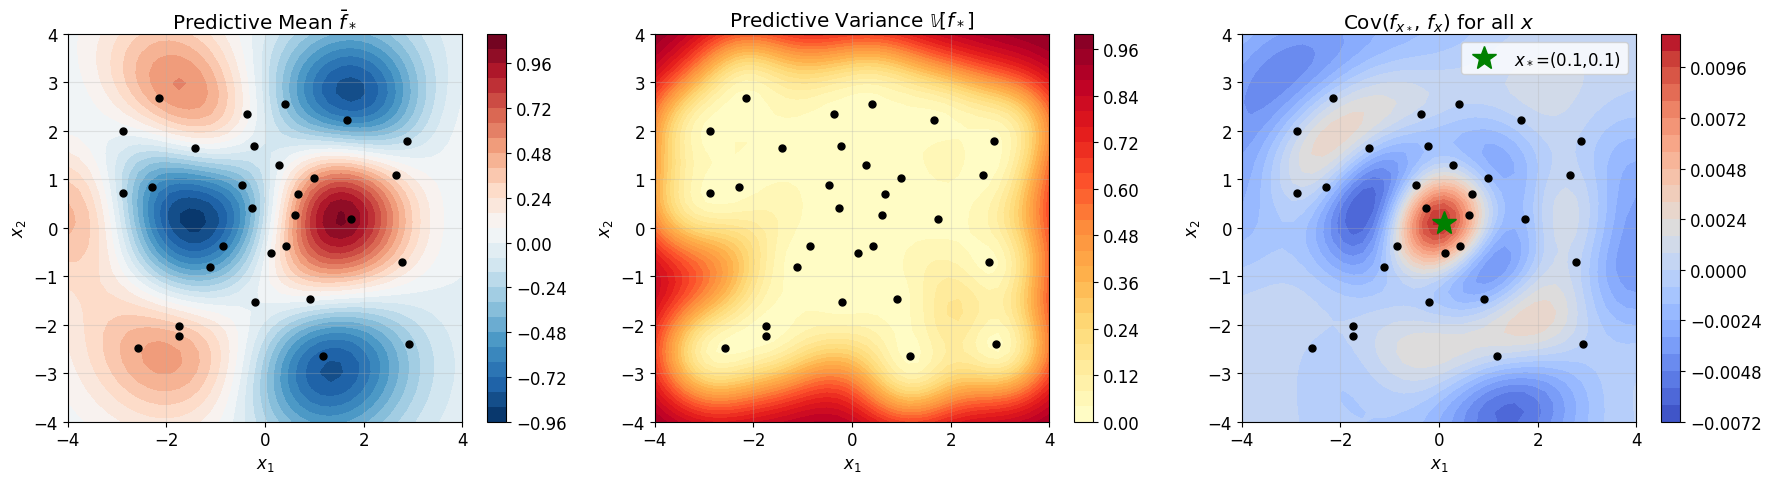


Test point x* = (0.10, 0.10)
Predictive mean  f_* = -0.0206
Predictive var   V[f_*] = 0.0105


In [7]:
np.random.seed(0)
n2d = 30
X_2d = np.random.uniform(-3, 3, (n2d, 2))
y_2d = np.sin(X_2d[:, 0]) * np.cos(X_2d[:, 1]) + 0.15 * np.random.randn(n2d)

kernel_2d = RBFKernel(length_scale=1.2, sigma_f=1.0)
gpr_2d = GPRegressor(kernel=kernel_2d, sigma_n=0.15)
gpr_2d.fit(X_2d, y_2d)

g = np.linspace(-4, 4, 40)
G1, G2 = np.meshgrid(g, g)
X_grid = np.column_stack([G1.ravel(), G2.ravel()])

f_mean_grid, f_cov_grid = gpr_2d.predict(X_grid, return_cov=True)
f_var_grid = np.diag(f_cov_grid)

# Pick a test input near centre
test_idx = len(g)//2 * len(g) + len(g)//2
x_star = X_grid[test_idx]
cov_with_star = f_cov_grid[test_idx, :]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].contourf(G1, G2, f_mean_grid.reshape(G1.shape), levels=25, cmap='RdBu_r')
axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c='k', s=25, zorder=5, label='Train')
axes[0].set_title('Predictive Mean $\\bar{f}_*$')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].contourf(G1, G2, f_var_grid.reshape(G1.shape), levels=25, cmap='YlOrRd')
axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c='k', s=25, zorder=5)
axes[1].set_title('Predictive Variance $\\mathbb{V}[f_*]$')
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].contourf(G1, G2, cov_with_star.reshape(G1.shape), levels=25, cmap='coolwarm')
axes[2].scatter(X_2d[:, 0], X_2d[:, 1], c='k', s=25, zorder=5)
axes[2].plot(x_star[0], x_star[1], 'g*', ms=18, zorder=6,
             label=f'$x_*$=({x_star[0]:.1f},{x_star[1]:.1f})')
axes[2].set_title('Cov($f_{x_*}$, $f_x$) for all $x$')
axes[2].legend()
plt.colorbar(im2, ax=axes[2])

for ax in axes:
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
plt.tight_layout(); plt.show()

print(f"\nTest point x* = ({x_star[0]:.2f}, {x_star[1]:.2f})")
print(f"Predictive mean  f_* = {f_mean_grid[test_idx]:.4f}")
print(f"Predictive var   V[f_*] = {f_var_grid[test_idx]:.4f}")

## 2.6 Multiple Test-Point Covariance Slices

Examine how covariance structure changes for test points at different distances from training data.

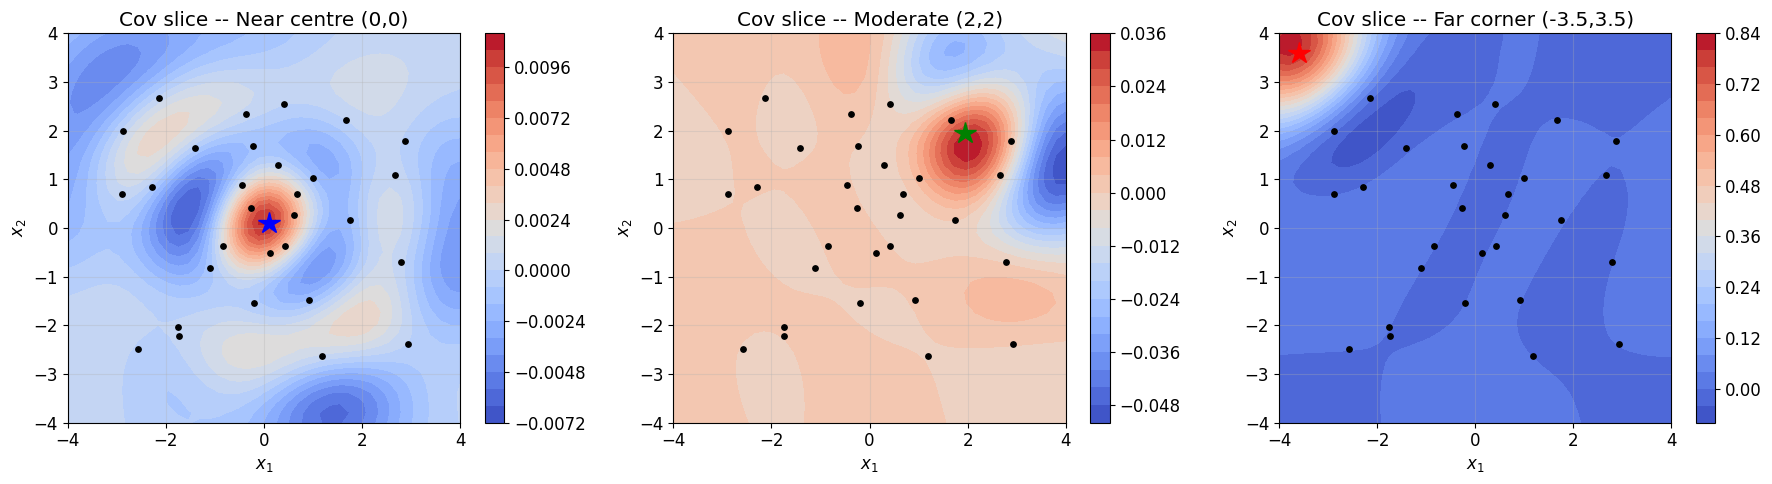

In [8]:
test_points_idx = [
    np.argmin(np.sum((X_grid - np.array([0, 0]))**2, axis=1)),
    np.argmin(np.sum((X_grid - np.array([2, 2]))**2, axis=1)),
    np.argmin(np.sum((X_grid - np.array([-3.5, 3.5]))**2, axis=1))
]
labels = ['Near centre (0,0)', 'Moderate (2,2)', 'Far corner (-3.5,3.5)']
colors = ['blue', 'green', 'red']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (idx, label, c) in enumerate(zip(test_points_idx, labels, colors)):
    cov_slice = f_cov_grid[idx, :]
    im = axes[i].contourf(G1, G2, cov_slice.reshape(G1.shape), levels=25, cmap='coolwarm')
    axes[i].scatter(X_2d[:, 0], X_2d[:, 1], c='k', s=15, zorder=5)
    xp = X_grid[idx]
    axes[i].plot(xp[0], xp[1], '*', color=c, ms=16, zorder=6)
    axes[i].set_title(f'Cov slice -- {label}')
    axes[i].set_xlabel('$x_1$'); axes[i].set_ylabel('$x_2$')
    plt.colorbar(im, ax=axes[i])
plt.tight_layout(); plt.show()

---
# Part 3: Algorithm 3.1 : Mode Finding (Newton's Method for Laplace Approximation)
---

For GP classification, the likelihood $p(\mathbf{y}|\mathbf{f})$ is non-Gaussian (logistic), so the posterior is intractable. The **Laplace approximation** approximates it with a Gaussian centred at the **mode** $\hat{\mathbf{f}}$.

**Algorithm 3.1** iteratively finds $\hat{\mathbf{f}}$ using Newton's method:

1. Initialise $\mathbf{f} := \mathbf{0}$
2. **Repeat** until convergence:
   - $W := -\nabla\nabla \log p(\mathbf{y}|\mathbf{f})$
   - $L := \text{cholesky}(I + W^{1/2} K W^{1/2})$
   - $\mathbf{b} := W\mathbf{f} + \nabla \log p(\mathbf{y}|\mathbf{f})$
   - $\mathbf{a} := \mathbf{b} - W^{1/2} L^\top \backslash (L \backslash (W^{1/2} K \mathbf{b}))$ (Eq. 3.18 via 3.27)
   - $\mathbf{f} := K\mathbf{a}$
3. $\log q(\mathbf{y}|X,\theta) := -\tfrac{1}{2}\mathbf{a}^\top\mathbf{f} + \log p(\mathbf{y}|\mathbf{f}) - \sum_i \log L_{ii}$ (Eq. 3.32)

## 3.1 Logistic Likelihood Utilities

For binary classification with labels $y_i \in \{-1, +1\}$:

$$\log p(y_i | f_i) = -\log(1 + \exp(-y_i f_i))$$

$$\frac{\partial}{\partial f_i} \log p(y_i | f_i) = t_i - \pi_i \qquad \text{where } t_i = (y_i + 1)/2, \; \pi_i = \sigma(f_i)$$

$$\frac{\partial^2}{\partial f_i^2} \log p(y_i | f_i) = -\pi_i(1 - \pi_i)$$

In [9]:
def logistic_log_likelihood(y, f):
    '''log p(y|f) for logistic likelihood, y in {-1,+1}.'''
    return -np.log(1 + np.exp(-y * f))

def logistic_grad(y, f):
    '''Gradient: d/df log p(y|f) = t - pi.'''
    t = (y + 1.0) / 2.0
    pi = expit(f)
    return t - pi

def logistic_hessian_diag(f):
    '''Negative second derivative: W_ii = pi*(1-pi).'''
    pi = expit(f)
    return pi * (1 - pi)


print("Logistic likelihood functions defined.")

Logistic likelihood functions defined.


## 3.2 Algorithm 3.1 Implementation

In [10]:
def laplace_mode_finding(K, y, max_iter=30, tol=1e-6):
    '''Algorithm 3.1: Find posterior mode via Newton iterations.

    Parameters
    ----------
    K : (n, n) covariance matrix
    y : (n,) labels in {-1, +1}

    Returns
    -------
    f_hat : (n,) posterior mode
    log_q : float, approximate log marginal likelihood
    info  : dict with convergence history
    '''
    n = len(y)
    f = np.zeros(n)
    objectives = []

    for it in range(max_iter):
        # W = -nabla nabla log p(y|f)  (diagonal)
        W_diag = logistic_hessian_diag(f)
        W_sqrt = np.sqrt(W_diag)

        # L = cholesky(I + W^{1/2} K W^{1/2})
        B = np.eye(n) + np.outer(W_sqrt, W_sqrt) * K
        L = cholesky(B, lower=True)

        # b = W f + nabla log p(y|f)
        grad = logistic_grad(y, f)
        b = W_diag * f + grad

        # a = b - W^{1/2} L^T \ (L \ (W^{1/2} K b))
        Kb = K @ b
        tmp1 = W_sqrt * Kb
        tmp2 = solve_triangular(L, tmp1, lower=True)
        tmp3 = solve_triangular(L.T, tmp2, lower=False)
        a = b - W_sqrt * tmp3

        # f = K a
        f_new = K @ a

        # Objective
        ll = np.sum(logistic_log_likelihood(y, f_new))
        obj = -0.5 * a @ f_new + ll
        objectives.append(obj)

        # Convergence check
        if np.max(np.abs(f_new - f)) < tol:
            f = f_new
            break
        f = f_new

    # log q(y|X,theta) = -0.5 a^T f + log p(y|f) - sum log L_ii
    log_q = (-0.5 * a @ f + np.sum(logistic_log_likelihood(y, f))
             - np.sum(np.log(np.diag(L))))

    info = {
        'iterations': it + 1,
        'objectives': objectives,
        'W_diag': W_diag,
        'L': L,
        'a': a,
    }
    return f, log_q, info


print("Algorithm 3.1 (Laplace mode-finding) implemented.")

Algorithm 3.1 (Laplace mode-finding) implemented.


---
# Part 4: Algorithm 3.2 : Predictions for Binary Laplace GP Classification
---

Given the posterior mode $\hat{\mathbf{f}}$ from Algorithm 3.1, we compute predictive class probabilities:

1. $\bar{f}_* := \mathbf{k}(\mathbf{x}_*)^\top \nabla \log p(\mathbf{y}|\hat{\mathbf{f}})$ (Eq. 3.21)
2. $\mathbf{v} := L \backslash (W^{1/2} \mathbf{k}(\mathbf{x}_*))$
3. $\mathbb{V}[f_*] := k(\mathbf{x}_*, \mathbf{x}_*) - \mathbf{v}^\top\mathbf{v}$ (Eq. 3.24 via 3.29)
4. $\bar{\pi}_* := \int \sigma(z) \mathcal{N}(z | \bar{f}_*, \mathbb{V}[f_*]) \, dz$ (Eq. 3.25)

## 4.1 Implementation

In [11]:
def sigmoid_integral_approx(f_mean, f_var):
    '''Approximate integral of sigma(z) * N(z|f_mean, f_var) dz.

    Uses the probit approximation:
        bar_pi = Phi(f_mean / sqrt(1 + pi*f_var/8))
    '''
    kappa = 1.0 / np.sqrt(1.0 + np.pi * f_var / 8.0)
    return expit(kappa * f_mean)


class GPClassifierLaplace:
    '''Binary GP Classifier using the Laplace Approximation.
    Implements Algorithms 3.1 (mode finding) and 3.2 (predictions).
    Labels should be in {-1, +1}.
    '''

    def __init__(self, kernel, max_iter=30, tol=1e-6):
        self.kernel = kernel
        self.max_iter = max_iter
        self.tol = tol
        self._is_fitted = False

    def fit(self, X, y):
        '''Find the posterior mode using Algorithm 3.1.'''
        self.X_train = np.atleast_2d(X)
        self.y_train = y.ravel().astype(float)
        assert set(np.unique(self.y_train)).issubset({-1.0, 1.0}), \
            "Labels must be in {-1, +1}"

        self.K = self.kernel(self.X_train, self.X_train)
        self.f_hat, self.log_q, self.info = laplace_mode_finding(
            self.K, self.y_train, self.max_iter, self.tol
        )
        self._is_fitted = True
        return self

    def predict_latent(self, X_star):
        '''Algorithm 3.2: compute latent mean and variance.'''
        assert self._is_fitted, "Call fit() first."
        X_star = np.atleast_2d(X_star)

        W_diag = self.info['W_diag']
        W_sqrt = np.sqrt(W_diag)
        L = self.info['L']

        k_star = self.kernel(self.X_train, X_star)

        # Eq. 3.21
        grad = logistic_grad(self.y_train, self.f_hat)
        f_mean = k_star.T @ grad

        # Eq. 3.24 / 3.29
        f_var = np.zeros(X_star.shape[0])
        for i in range(X_star.shape[0]):
            ki = k_star[:, i]
            vi = solve_triangular(L, W_sqrt * ki, lower=True)
            k_ss = self.kernel.diag(X_star[i:i+1])[0]
            f_var[i] = k_ss - vi @ vi

        f_var = np.maximum(f_var, 1e-10)
        return f_mean, f_var

    def predict_proba(self, X_star):
        '''Eq. 3.25: averaged predictive probability.'''
        f_mean, f_var = self.predict_latent(X_star)
        pi_star = sigmoid_integral_approx(f_mean, f_var)
        return pi_star

    def predict(self, X_star, threshold=0.5):
        '''Return predicted labels in {-1, +1}.'''
        pi_star = self.predict_proba(X_star)
        return np.where(pi_star >= threshold, 1.0, -1.0)


print("GPClassifierLaplace (Algorithms 3.1 + 3.2) implemented.")

GPClassifierLaplace (Algorithms 3.1 + 3.2) implemented.


## 4.2 Newton Convergence Demo

We show how the objective converges during Newton iterations of Algorithm 3.1.

Converged in 5 iterations
Approx. log marginal likelihood: -22.7880


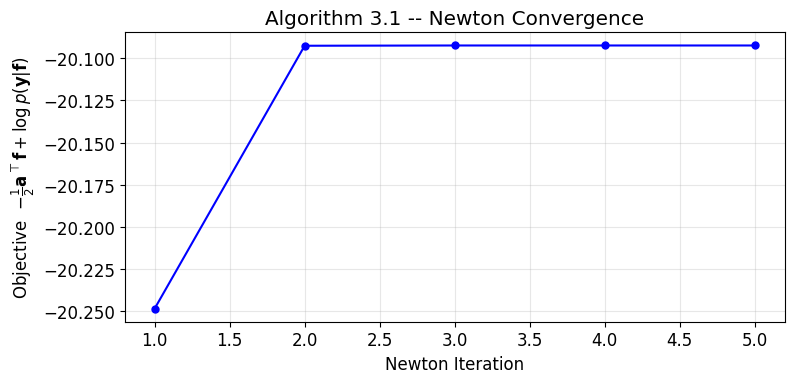

In [12]:
np.random.seed(7)
n_demo = 50
X_demo = np.random.randn(n_demo, 2)
y_demo = np.sign(X_demo[:, 0] + 0.5*X_demo[:, 1] + 0.3*np.random.randn(n_demo))

kernel_demo = RBFKernel(length_scale=1.0, sigma_f=1.0)
clf_demo = GPClassifierLaplace(kernel=kernel_demo, max_iter=50)
clf_demo.fit(X_demo, y_demo)

print(f"Converged in {clf_demo.info['iterations']} iterations")
print(f"Approx. log marginal likelihood: {clf_demo.log_q:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(clf_demo.info['objectives'])+1),
        clf_demo.info['objectives'], 'b-o', ms=5)
ax.set_xlabel('Newton Iteration')
ax.set_ylabel('Objective  $-\\frac{1}{2}\\mathbf{a}^\\top\\mathbf{f} + \\log p(\\mathbf{y}|\\mathbf{f})$')
ax.set_title('Algorithm 3.1 -- Newton Convergence')
plt.tight_layout(); plt.show()

---
# Part 5: Binary GP Classification : Experiments
---

## 5.1 Experiment 1: Two Moons Dataset

In [13]:
np.random.seed(42)
X_moons, y_moons_01 = make_moons(n_samples=200, noise=0.2, random_state=42)
y_moons = 2 * y_moons_01 - 1  # {0,1} -> {-1,+1}

scaler_m = StandardScaler()
X_moons = scaler_m.fit_transform(X_moons)

X_m_train, X_m_test, y_m_train, y_m_test = train_test_split(
    X_moons, y_moons, test_size=0.3, random_state=42
)

kernel_m = RBFKernel(length_scale=0.8, sigma_f=1.0)
clf_moons = GPClassifierLaplace(kernel=kernel_m)
clf_moons.fit(X_m_train, y_m_train)

y_pred_m = clf_moons.predict(X_m_test)
acc_m = accuracy_score(y_m_test, y_pred_m)
print(f"Two Moons -- Accuracy: {acc_m:.4f}")
print(f"Approx. log marginal likelihood: {clf_moons.log_q:.4f}")
print(f"Newton iterations: {clf_moons.info['iterations']}")
print(f"\nClassification Report:")
print(classification_report(y_m_test, y_pred_m, target_names=['Class -1', 'Class +1']))

Two Moons -- Accuracy: 0.9833
Approx. log marginal likelihood: -54.0755
Newton iterations: 5

Classification Report:
              precision    recall  f1-score   support

    Class -1       0.97      1.00      0.98        32
    Class +1       1.00      0.96      0.98        28

    accuracy                           0.98        60
   macro avg       0.98      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60



### Decision Boundary and Predictive Uncertainty

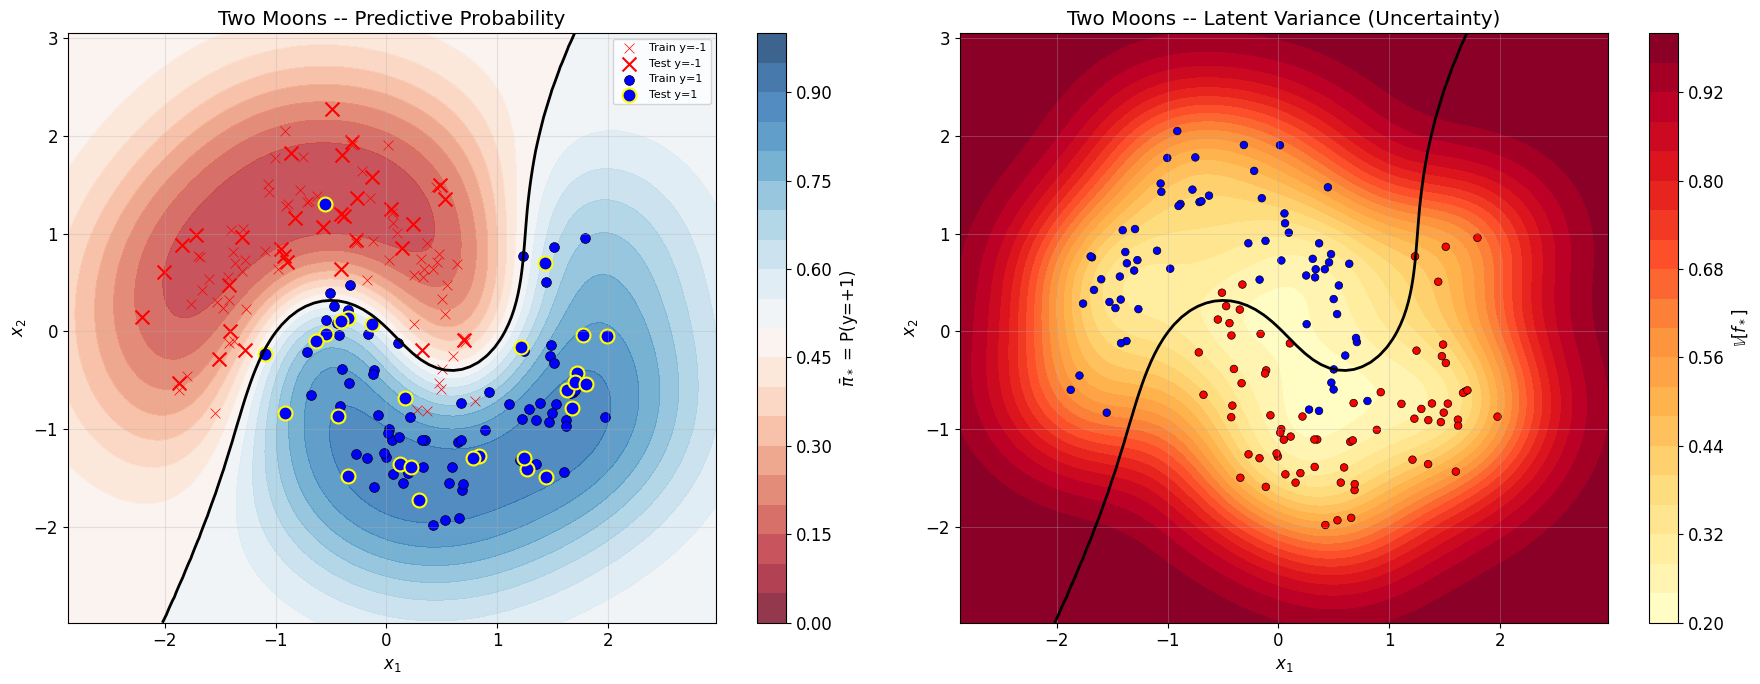

In [14]:
def plot_gpc_decision_boundary(clf, X_train, y_train, X_test, y_test, title="",
                               ax=None, resolution=80):
    '''Plot decision boundary with class probabilities and uncertainty.'''
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 7))

    x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
    y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, resolution),
                         np.linspace(y_min, y_max, resolution))
    X_grid = np.c_[xx.ravel(), yy.ravel()]

    pi_grid = clf.predict_proba(X_grid).reshape(xx.shape)
    f_mean_g, f_var_g = clf.predict_latent(X_grid)

    contour = ax.contourf(xx, yy, pi_grid, levels=np.linspace(0, 1, 21),
                          cmap='RdBu', alpha=0.8)
    ax.contour(xx, yy, pi_grid, levels=[0.5], colors='k', linewidths=2)
    plt.colorbar(contour, ax=ax, label='$\\bar{\\pi}_*$ = P(y=+1)')

    for label, marker, color in [(-1, 'x', 'red'), (1, 'o', 'blue')]:
        mask_tr = y_train == label
        mask_te = y_test == label
        ax.scatter(X_train[mask_tr, 0], X_train[mask_tr, 1],
                   marker=marker, c=color, s=50, edgecolors='k', lw=0.5,
                   label=f'Train y={label}')
        ax.scatter(X_test[mask_te, 0], X_test[mask_te, 1],
                   marker=marker, c=color, s=100, edgecolors='yellow', lw=1.5,
                   label=f'Test y={label}')

    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    ax.set_title(title)
    ax.legend(loc='best', fontsize=8)
    return f_mean_g, f_var_g, xx, yy


fig, axes = plt.subplots(1, 2, figsize=(18, 7))

f_mg, f_vg, xx, yy = plot_gpc_decision_boundary(
    clf_moons, X_m_train, y_m_train, X_m_test, y_m_test,
    title='Two Moons -- Predictive Probability', ax=axes[0])

# Variance map
im1 = axes[1].contourf(xx, yy, f_vg.reshape(xx.shape), levels=25, cmap='YlOrRd')
axes[1].contour(xx, yy, clf_moons.predict_proba(
    np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape),
    levels=[0.5], colors='k', linewidths=2)
axes[1].scatter(X_m_train[:, 0], X_m_train[:, 1], c=y_m_train,
               cmap='bwr', s=30, edgecolors='k', lw=0.5)
plt.colorbar(im1, ax=axes[1], label='$\\mathbb{V}[f_*]$')
axes[1].set_xlabel('$x_1$'); axes[1].set_ylabel('$x_2$')
axes[1].set_title('Two Moons -- Latent Variance (Uncertainty)')

plt.tight_layout(); plt.show()

### Interpreting the Uncertainty

The **predictive variance** $\mathbb{V}[f_*]$ highlights regions where the GP is uncertain:

- **Near the decision boundary**: variance is highest because the latent function is close to zero.
- **Far from training data**: variance increases as the GP reverts to its prior.
- **Near training points**: variance is lowest since observations constrain the latent function.

The **averaged prediction** $\bar{\pi}_*$ integrates over this uncertainty, producing more conservative probabilities than the MAP prediction in uncertain regions.

## 5.2 Experiment 2: Iris Dataset (Binary : Setosa vs. Non-Setosa)

Iris binary -- Accuracy: 0.9778
Newton iterations: 7


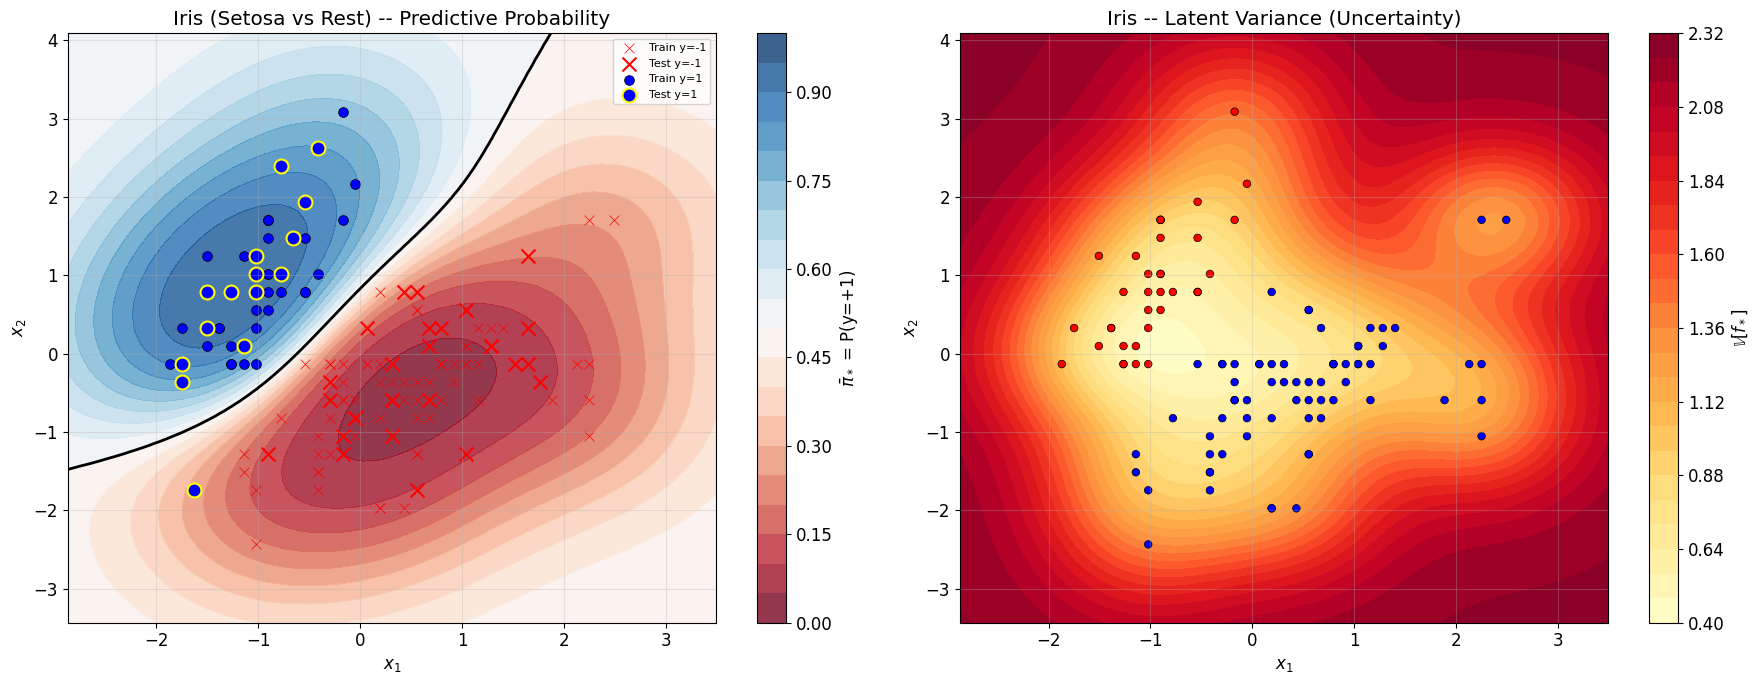

In [15]:
iris = load_iris()
X_iris = iris.data[:, :2]
y_iris = np.where(iris.target == 0, 1.0, -1.0)

scaler_i = StandardScaler()
X_iris = scaler_i.fit_transform(X_iris)

X_i_train, X_i_test, y_i_train, y_i_test = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=42, stratify=y_iris
)

kernel_i = RBFKernel(length_scale=1.0, sigma_f=1.5)
clf_iris = GPClassifierLaplace(kernel=kernel_i)
clf_iris.fit(X_i_train, y_i_train)

y_pred_i = clf_iris.predict(X_i_test)
acc_i = accuracy_score(y_i_test, y_pred_i)
print(f"Iris binary -- Accuracy: {acc_i:.4f}")
print(f"Newton iterations: {clf_iris.info['iterations']}")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
plot_gpc_decision_boundary(clf_iris, X_i_train, y_i_train, X_i_test, y_i_test,
                           'Iris (Setosa vs Rest) -- Predictive Probability', ax=axes[0])

resolution = 80
x_min, x_max = X_i_train[:, 0].min() - 1, X_i_train[:, 0].max() + 1
y_min, y_max = X_i_train[:, 1].min() - 1, X_i_train[:, 1].max() + 1
xx_i, yy_i = np.meshgrid(np.linspace(x_min, x_max, resolution),
                          np.linspace(y_min, y_max, resolution))
_, fv_iris = clf_iris.predict_latent(np.c_[xx_i.ravel(), yy_i.ravel()])
im = axes[1].contourf(xx_i, yy_i, fv_iris.reshape(xx_i.shape), levels=25, cmap='YlOrRd')
axes[1].scatter(X_i_train[:, 0], X_i_train[:, 1], c=y_i_train, cmap='bwr',
               s=30, edgecolors='k', lw=0.5)
plt.colorbar(im, ax=axes[1], label='$\\mathbb{V}[f_*]$')
axes[1].set_xlabel('$x_1$'); axes[1].set_ylabel('$x_2$')
axes[1].set_title('Iris -- Latent Variance (Uncertainty)')

plt.tight_layout(); plt.show()

## 5.3 MAP vs. Averaged Prediction Comparison

The MAP prediction $\hat{\pi}_* = \sigma(\bar{f}_*)$ ignores latent variance, while the averaged prediction $\bar{\pi}_*$ accounts for uncertainty.

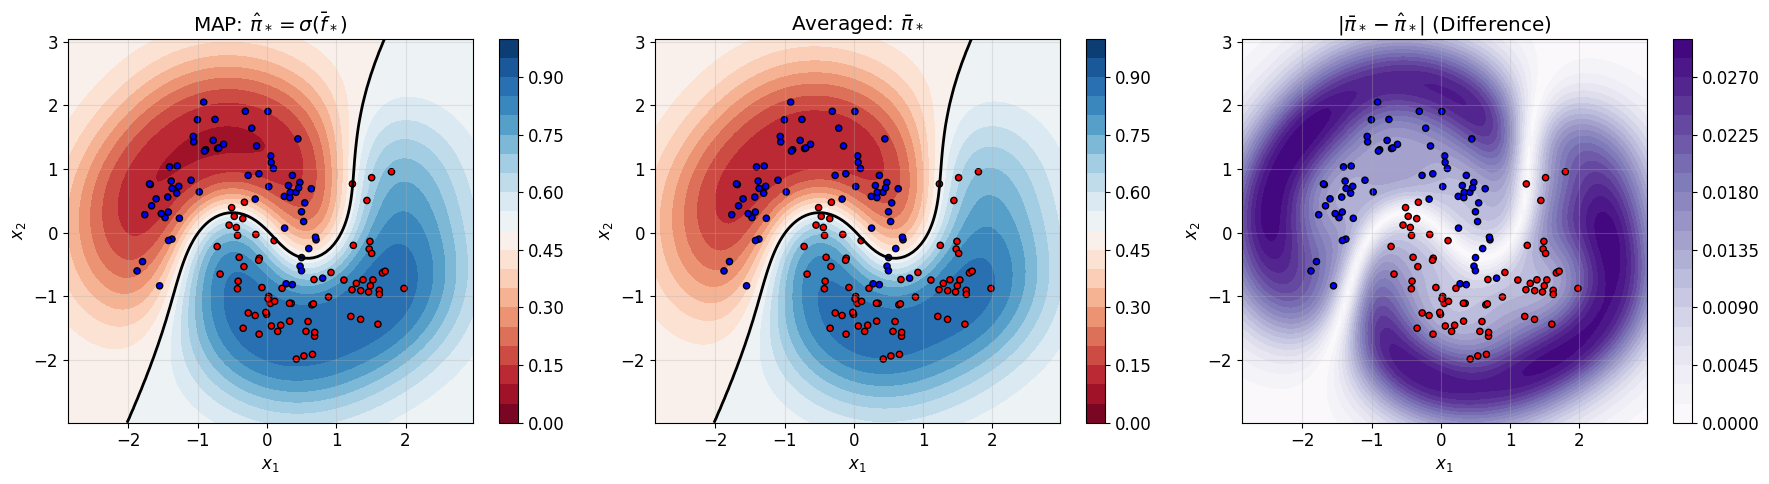

The difference is largest near the decision boundary and far from data,
where latent variance is high -- the averaged prediction is more conservative.


In [16]:
resolution = 100
x_min, x_max = X_m_train[:, 0].min() - 1, X_m_train[:, 0].max() + 1
y_min, y_max = X_m_train[:, 1].min() - 1, X_m_train[:, 1].max() + 1
xx_c, yy_c = np.meshgrid(np.linspace(x_min, x_max, resolution),
                          np.linspace(y_min, y_max, resolution))
X_gc = np.c_[xx_c.ravel(), yy_c.ravel()]

f_mean_c, f_var_c = clf_moons.predict_latent(X_gc)
pi_map = expit(f_mean_c)
pi_avg = sigmoid_integral_approx(f_mean_c, f_var_c)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].contourf(xx_c, yy_c, pi_map.reshape(xx_c.shape),
                        levels=np.linspace(0, 1, 21), cmap='RdBu')
axes[0].contour(xx_c, yy_c, pi_map.reshape(xx_c.shape), levels=[0.5], colors='k', linewidths=2)
axes[0].scatter(X_m_train[:, 0], X_m_train[:, 1], c=y_m_train, cmap='bwr', s=20, edgecolors='k')
axes[0].set_title('MAP: $\\hat{\\pi}_* = \\sigma(\\bar{f}_*)$')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].contourf(xx_c, yy_c, pi_avg.reshape(xx_c.shape),
                        levels=np.linspace(0, 1, 21), cmap='RdBu')
axes[1].contour(xx_c, yy_c, pi_avg.reshape(xx_c.shape), levels=[0.5], colors='k', linewidths=2)
axes[1].scatter(X_m_train[:, 0], X_m_train[:, 1], c=y_m_train, cmap='bwr', s=20, edgecolors='k')
axes[1].set_title('Averaged: $\\bar{\\pi}_*$')
plt.colorbar(im1, ax=axes[1])

diff = np.abs(pi_avg - pi_map)
im2 = axes[2].contourf(xx_c, yy_c, diff.reshape(xx_c.shape), levels=25, cmap='Purples')
axes[2].scatter(X_m_train[:, 0], X_m_train[:, 1], c=y_m_train, cmap='bwr', s=20, edgecolors='k')
axes[2].set_title('$|\\bar{\\pi}_* - \\hat{\\pi}_*|$ (Difference)')
plt.colorbar(im2, ax=axes[2])

for ax in axes:
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
plt.tight_layout(); plt.show()

print("The difference is largest near the decision boundary and far from data,")
print("where latent variance is high -- the averaged prediction is more conservative.")

---
# Part 6: Hyperparameter Analysis
---

## 6.1 Effect of Length Scale $\ell$ on GP Regression

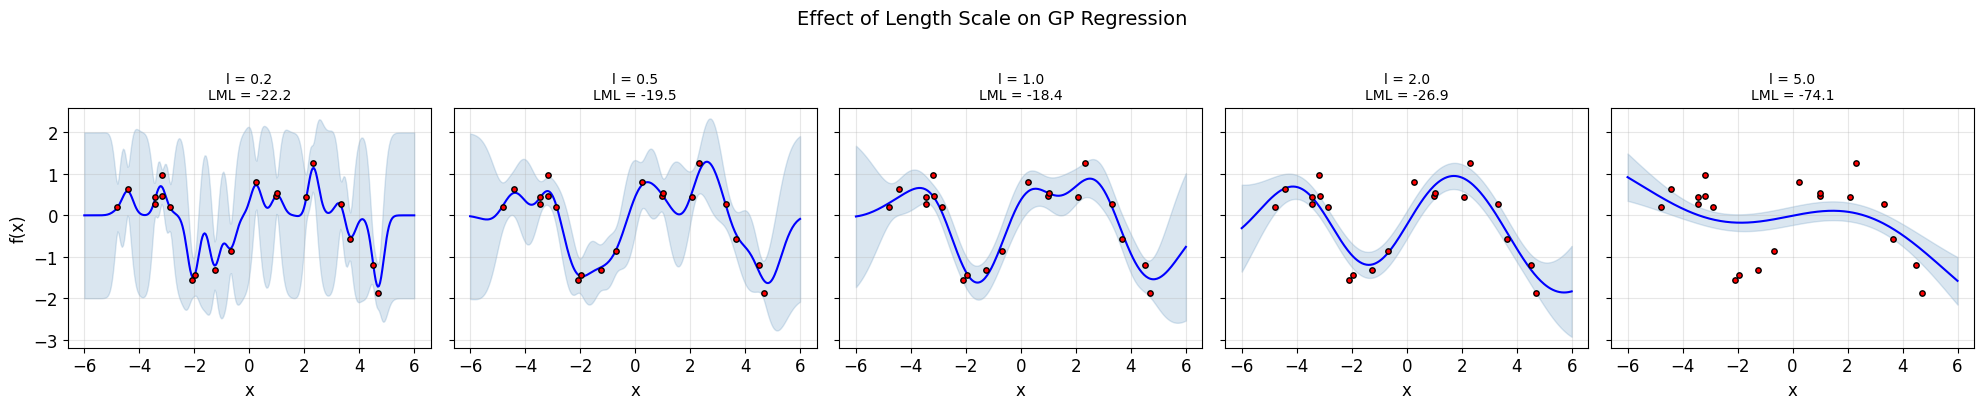

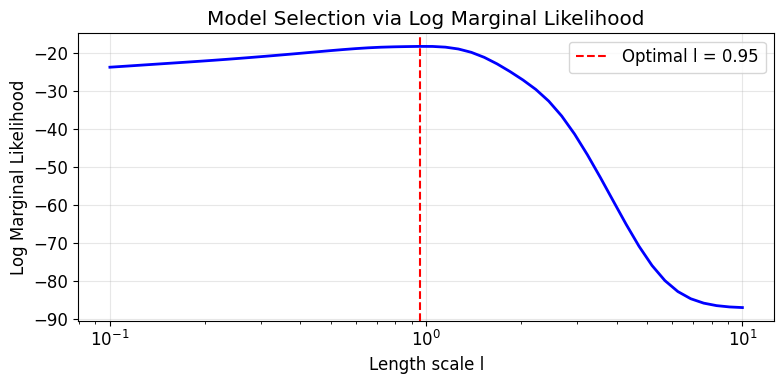

In [17]:
length_scales = [0.2, 0.5, 1.0, 2.0, 5.0]

fig, axes = plt.subplots(1, len(length_scales), figsize=(4*len(length_scales), 4), sharey=True)
lmls = []
for i, ls in enumerate(length_scales):
    k = RBFKernel(length_scale=ls, sigma_f=1.0)
    gp = GPRegressor(kernel=k, sigma_n=noise_std)
    gp.fit(X_train_1d, y_train_1d)
    fm, fv = gp.predict(X_test_1d)
    fs = np.sqrt(fv)
    lml = gp.log_marginal_likelihood()
    lmls.append(lml)

    axes[i].plot(X_test_1d, fm, 'b-', lw=1.5)
    axes[i].fill_between(X_test_1d.ravel(), fm-2*fs, fm+2*fs, alpha=0.2, color='steelblue')
    axes[i].scatter(X_train_1d, y_train_1d, c='red', s=15, zorder=5, edgecolors='k')
    axes[i].set_title(f'l = {ls}\nLML = {lml:.1f}', fontsize=10)
    axes[i].set_xlabel('x')
    if i == 0:
        axes[i].set_ylabel('f(x)')

plt.suptitle('Effect of Length Scale on GP Regression', y=1.02, fontsize=14)
plt.tight_layout(); plt.show()

# LML vs length scale (finer grid)
ls_grid = np.logspace(-1, 1, 50)
lml_grid = []
for ls in ls_grid:
    k = RBFKernel(length_scale=ls, sigma_f=1.0)
    gp = GPRegressor(kernel=k, sigma_n=noise_std)
    gp.fit(X_train_1d, y_train_1d)
    lml_grid.append(gp.log_marginal_likelihood())

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(ls_grid, lml_grid, 'b-', lw=2)
ax.set_xlabel('Length scale l')
ax.set_ylabel('Log Marginal Likelihood')
ax.set_title('Model Selection via Log Marginal Likelihood')
ax.axvline(ls_grid[np.argmax(lml_grid)], color='r', ls='--',
           label=f'Optimal l = {ls_grid[np.argmax(lml_grid)]:.2f}')
ax.legend()
plt.tight_layout(); plt.show()

## 6.2 Effect of Noise Level $\sigma_n$ on GP Regression

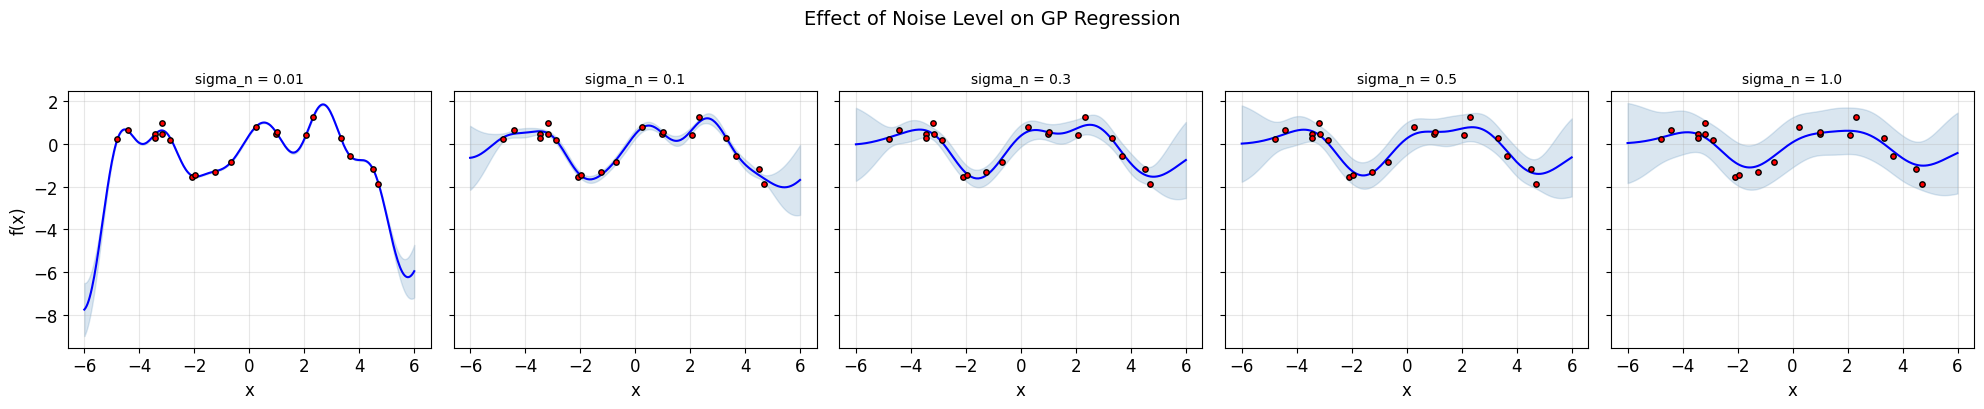

In [18]:
sigma_ns = [0.01, 0.1, 0.3, 0.5, 1.0]

fig, axes = plt.subplots(1, len(sigma_ns), figsize=(4*len(sigma_ns), 4), sharey=True)
for i, sn in enumerate(sigma_ns):
    k = RBFKernel(length_scale=1.0, sigma_f=1.0)
    gp = GPRegressor(kernel=k, sigma_n=sn)
    gp.fit(X_train_1d, y_train_1d)
    fm, fv = gp.predict(X_test_1d)
    fs = np.sqrt(fv)

    axes[i].plot(X_test_1d, fm, 'b-', lw=1.5)
    axes[i].fill_between(X_test_1d.ravel(), fm-2*fs, fm+2*fs, alpha=0.2, color='steelblue')
    axes[i].scatter(X_train_1d, y_train_1d, c='red', s=15, zorder=5, edgecolors='k')
    axes[i].set_title(f'sigma_n = {sn}', fontsize=10)
    axes[i].set_xlabel('x')
    if i == 0:
        axes[i].set_ylabel('f(x)')

plt.suptitle('Effect of Noise Level on GP Regression', y=1.02, fontsize=14)
plt.tight_layout(); plt.show()

## 6.3 Effect of Length Scale on GP Classification

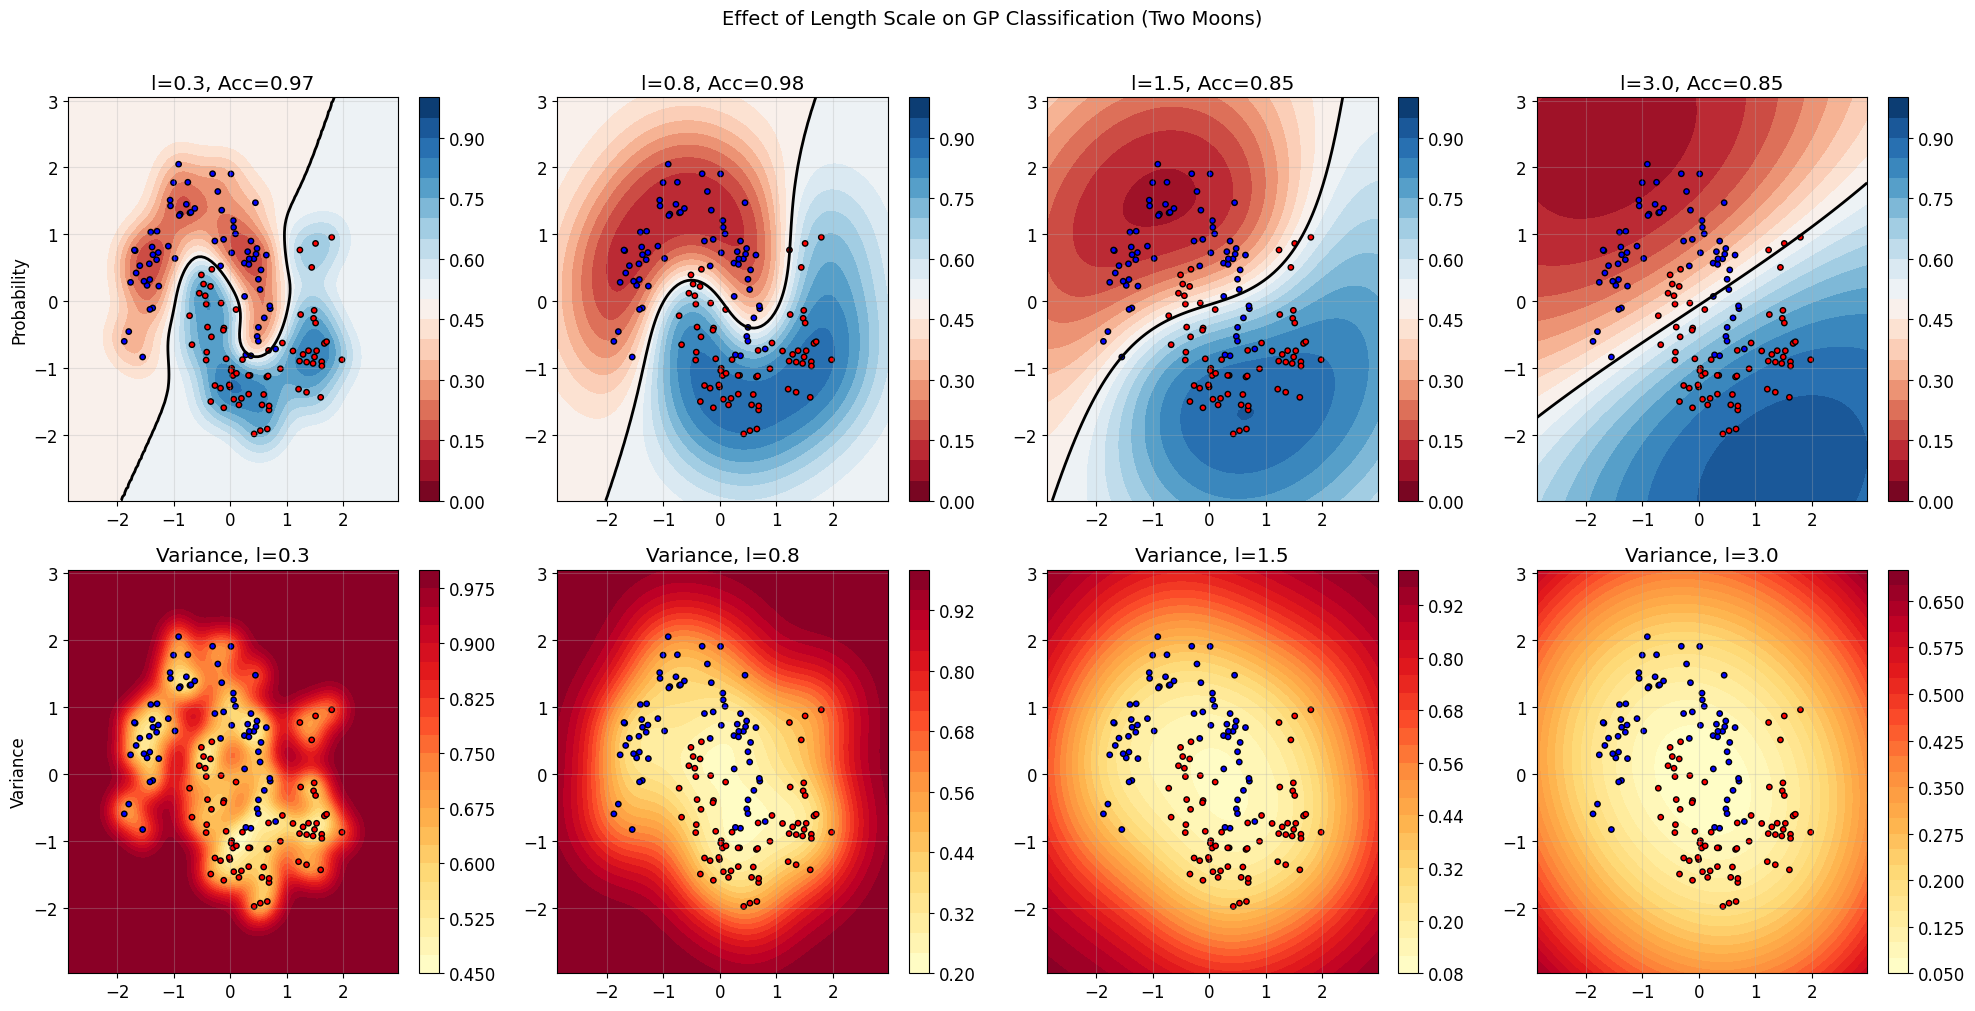

In [19]:
length_scales_clf = [0.3, 0.8, 1.5, 3.0]

fig, axes = plt.subplots(2, len(length_scales_clf),
                         figsize=(5*len(length_scales_clf), 10))

for i, ls in enumerate(length_scales_clf):
    k = RBFKernel(length_scale=ls, sigma_f=1.0)
    clf = GPClassifierLaplace(kernel=k)
    clf.fit(X_m_train, y_m_train)

    y_pred = clf.predict(X_m_test)
    acc = accuracy_score(y_m_test, y_pred)

    pi_g = clf.predict_proba(X_gc).reshape(xx_c.shape)
    _, fv_g = clf.predict_latent(X_gc)

    im0 = axes[0, i].contourf(xx_c, yy_c, pi_g, levels=np.linspace(0,1,21), cmap='RdBu')
    axes[0, i].contour(xx_c, yy_c, pi_g, levels=[0.5], colors='k', linewidths=2)
    axes[0, i].scatter(X_m_train[:, 0], X_m_train[:, 1], c=y_m_train, cmap='bwr', s=15, edgecolors='k')
    axes[0, i].set_title(f'l={ls}, Acc={acc:.2f}')
    plt.colorbar(im0, ax=axes[0, i])

    im1 = axes[1, i].contourf(xx_c, yy_c, fv_g.reshape(xx_c.shape), levels=25, cmap='YlOrRd')
    axes[1, i].scatter(X_m_train[:, 0], X_m_train[:, 1], c=y_m_train, cmap='bwr', s=15, edgecolors='k')
    axes[1, i].set_title(f'Variance, l={ls}')
    plt.colorbar(im1, ax=axes[1, i])

axes[0, 0].set_ylabel('Probability')
axes[1, 0].set_ylabel('Variance')
plt.suptitle('Effect of Length Scale on GP Classification (Two Moons)', y=1.01, fontsize=14)
plt.tight_layout(); plt.show()

## 6.4 Kernel Comparison for GP Regression

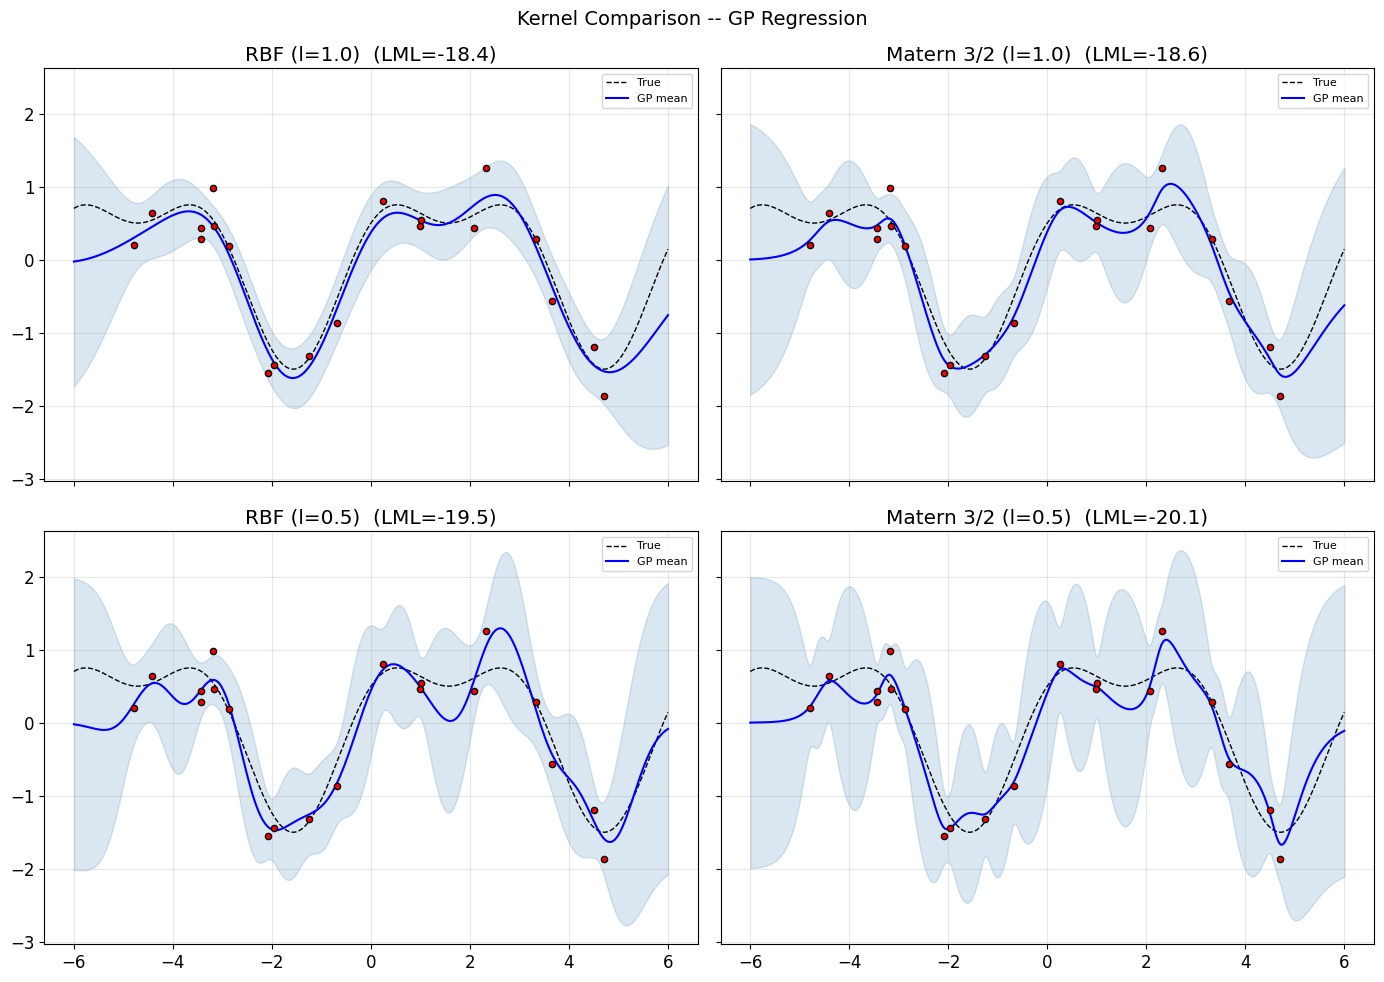

In [20]:
kernels_cmp = {
    'RBF (l=1.0)': RBFKernel(length_scale=1.0, sigma_f=1.0),
    'Matern 3/2 (l=1.0)': Matern32Kernel(length_scale=1.0, sigma_f=1.0),
    'RBF (l=0.5)': RBFKernel(length_scale=0.5, sigma_f=1.0),
    'Matern 3/2 (l=0.5)': Matern32Kernel(length_scale=0.5, sigma_f=1.0),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True, sharex=True)
for ax, (name, kern) in zip(axes.ravel(), kernels_cmp.items()):
    gp = GPRegressor(kernel=kern, sigma_n=noise_std)
    gp.fit(X_train_1d, y_train_1d)
    fm, fv = gp.predict(X_test_1d)
    fs = np.sqrt(fv)

    ax.plot(X_test_1d, f_test_true, 'k--', lw=1, label='True')
    ax.plot(X_test_1d, fm, 'b-', lw=1.5, label='GP mean')
    ax.fill_between(X_test_1d.ravel(), fm-2*fs, fm+2*fs, alpha=0.2, color='steelblue')
    ax.scatter(X_train_1d, y_train_1d, c='red', s=20, zorder=5, edgecolors='k')
    ax.set_title(f'{name}  (LML={gp.log_marginal_likelihood():.1f})')
    ax.legend(fontsize=8)

plt.suptitle('Kernel Comparison -- GP Regression', fontsize=14)
plt.tight_layout(); plt.show()

---
# Part 7: Additional Analysis : Confusion Matrix and Reliability
---

## 7.1 Confusion Matrix for Classification

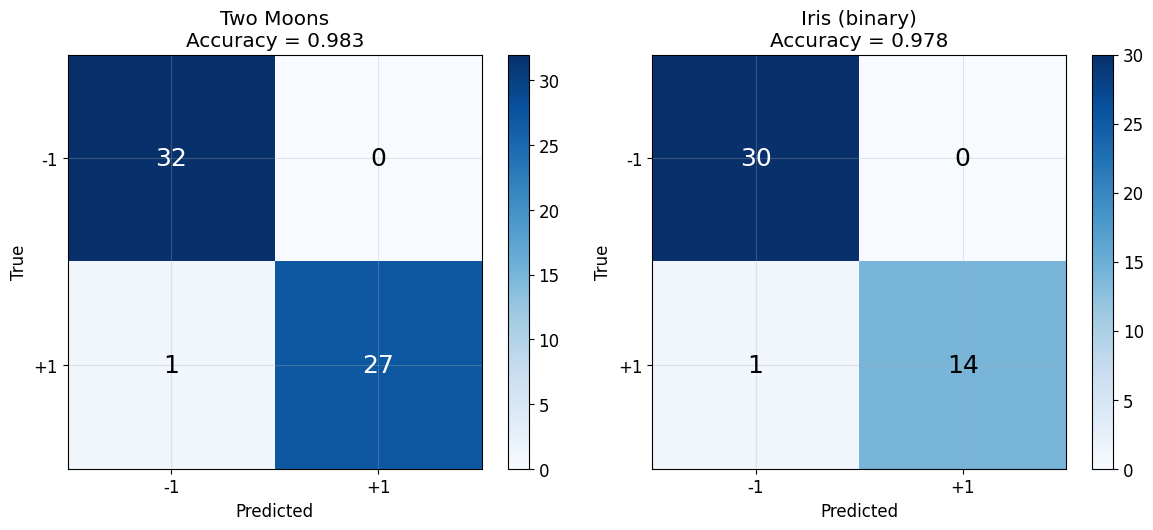

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, (name, clf, Xte, yte) in enumerate([
    ('Two Moons', clf_moons, X_m_test, y_m_test),
    ('Iris (binary)', clf_iris, X_i_test, y_i_test)
]):
    y_pred = clf.predict(Xte)
    cm = confusion_matrix(yte, y_pred, labels=[-1, 1])
    im = axes[i].imshow(cm, cmap='Blues', interpolation='nearest')
    axes[i].set_xticks([0, 1]); axes[i].set_yticks([0, 1])
    axes[i].set_xticklabels(['-1', '+1']); axes[i].set_yticklabels(['-1', '+1'])
    axes[i].set_xlabel('Predicted'); axes[i].set_ylabel('True')
    axes[i].set_title(f'{name}\nAccuracy = {accuracy_score(yte, y_pred):.3f}')
    for r in range(2):
        for c_idx in range(2):
            axes[i].text(c_idx, r, str(cm[r, c_idx]), ha='center', va='center',
                        fontsize=18, color='white' if cm[r, c_idx] > cm.max()/2 else 'black')
    plt.colorbar(im, ax=axes[i])

plt.tight_layout(); plt.show()

## 7.2 Reliability Diagram : Calibration of GP Classification

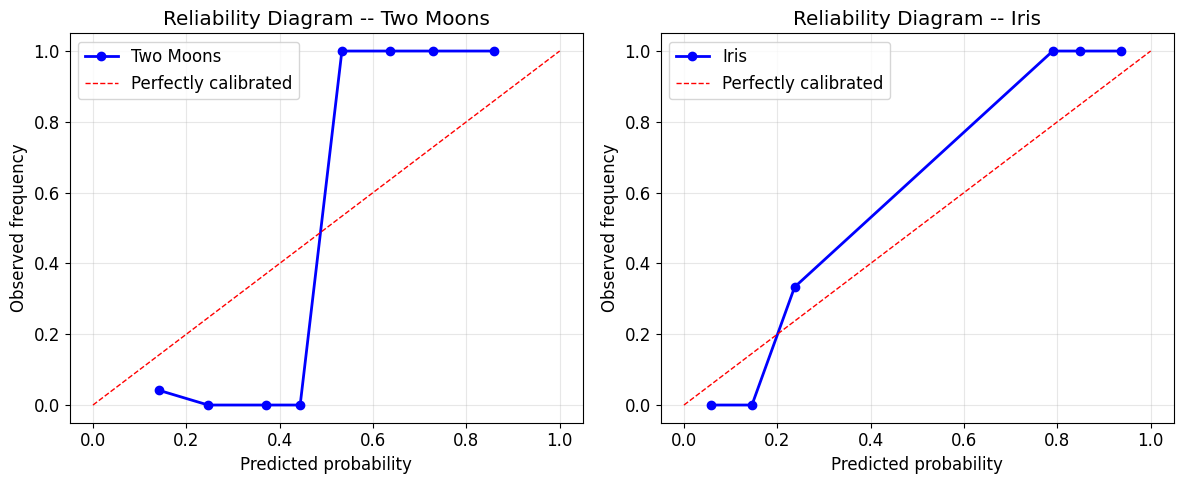

In [22]:
def reliability_diagram(clf, X_test, y_test, n_bins=10, ax=None, label=""):
    '''Plot reliability diagram (calibration curve).'''
    if ax is None:
        fig, ax = plt.subplots()
    pi = clf.predict_proba(X_test)
    y01 = (y_test + 1) / 2.0

    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_means = []
    bin_true = []
    for j in range(n_bins):
        mask = (pi >= bin_edges[j]) & (pi < bin_edges[j+1])
        if mask.sum() > 0:
            bin_means.append(pi[mask].mean())
            bin_true.append(y01[mask].mean())

    ax.plot(bin_means, bin_true, 'bo-', lw=2, ms=6, label=label or 'GP')
    ax.plot([0, 1], [0, 1], 'r--', lw=1, label='Perfectly calibrated')
    ax.set_xlabel('Predicted probability')
    ax.set_ylabel('Observed frequency')
    ax.legend()
    return ax

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
reliability_diagram(clf_moons, X_m_test, y_m_test, ax=axes[0], label='Two Moons')
axes[0].set_title('Reliability Diagram -- Two Moons')
reliability_diagram(clf_iris, X_i_test, y_i_test, ax=axes[1], label='Iris')
axes[1].set_title('Reliability Diagram -- Iris')
plt.tight_layout(); plt.show()

<!-- ---
# Part 8: Summary of Uncertainty in GP Predictions
---

## GP Regression (Algorithm 2.1)
The predictive variance $\mathbb{V}[f_*] = k(\mathbf{x}_*, \mathbf{x}_*) - \mathbf{v}^\top\mathbf{v}$ has key properties:
- It **decreases near training data** as observations constrain the function.
- It **increases away from training data** as the GP reverts to its prior.
- The variance depends **only on the input locations** and the kernel, not on the target values $\mathbf{y}$.

## GP Classification (Algorithms 3.1 + 3.2)
The uncertainty has an additional layer:

1. **Latent variance** $\mathbb{V}[f_*]$ captures uncertainty in the latent function, using the Laplace-approximated posterior covariance $(K + W^{-1})^{-1}$.

2. **Averaged prediction** $\bar{\pi}_* = \int \sigma(z) \mathcal{N}(z|\bar{f}_*, \mathbb{V}[f_*]) dz$ integrates over latent uncertainty:
   - Where variance is **low**: predictions are confident (close to 0 or 1).
   - Where variance is **high**: predictions are conservative (closer to 0.5).
   - This is **more principled** than the MAP prediction $\hat{\pi}_* = \sigma(\bar{f}_*)$.

3. The **difference** between MAP and averaged predictions is largest where the model is most uncertain.

## Hyperparameter Sensitivity
- **Length scale** $\ell$: Controls smoothness. Too small leads to overfitting, too large to underfitting.
- **Signal variance** $\sigma_f^2$: Controls amplitude of function variation.
- **Noise variance** $\sigma_n^2$ (regression): Balances data fit vs. smoothness.
- The **log marginal likelihood** provides a principled model selection criterion. -->

<!-- ---
*End of Report*
--- -->